In [1]:
import cdsapi

c = cdsapi.Client()
dataset = "reanalysis-era5-single-levels"

c.retrieve(
    dataset,
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure',
            'total_precipitation',
        ],
        'year': '2000',
        'month': '12',
        'day': [
            '06', '07', '08', '09', '10', '11', '12',
            '13', '14', '15', '16', '17'
        ],
        'time': [
            '00:00', '01:00', '02:00',
            '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00',
            '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00',
            '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00',
            '21:00', '22:00', '23:00',
        ],
        'area': [
            90, -60, 30,
            50,
        ],
    },
    'case2000_singlev_update_extended.nc')

2025-02-10 11:25:49,654 INFO Request ID is 112995d4-614f-46a9-b228-df43b45f4e8b
2025-02-10 11:25:49,943 INFO status has been updated to accepted
2025-02-10 11:25:58,292 INFO status has been updated to running
2025-02-10 11:27:45,198 INFO status has been updated to successful


17b120e2b8d506810d02fc3871b7a3c9.zip:   0%|          | 0.00/193M [00:00<?, ?B/s]

In [1]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'format': 'netcdf',
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'mean_sea_level_pressure',
        'year': [
            '1981', '1982', '1983',
            '1984', '1985', '1986',
            '1987', '1988', '1989',
            '1990', '1991', '1992',
            '1993', '1994', '1995',
            '1996', '1997', '1998',
            '1999', '2000', '2001',
            '2002', '2003', '2004',
            '2005', '2006', '2007',
            '2008', '2009', '2010',
        ],
        'month': '12',
        'time': '00:00',
        'area': [
            80, -45, 30,
            45,
        ],
    },
    'dec_mslp.nc')

2024-06-18 10:03:44,667 INFO Welcome to the CDS
2024-06-18 10:03:44,668 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels-monthly-means
2024-06-18 10:03:44,784 INFO Request is queued
2024-06-18 10:03:45,824 INFO Request is running
2024-06-18 10:03:53,076 INFO Request is completed
2024-06-18 10:03:53,077 INFO Downloading https://download-0003-clone.copernicus-climate.eu/cache-compute-0003/cache/data3/adaptor.mars.internal-1718705031.4355252-28890-1-80147de3-04a6-4bf1-af21-9bff5c7d0286.nc to dec_mslp.nc (4.2M)
2024-06-18 10:03:53,572 INFO Download rate 8.4M/s   


Result(content_length=4357160,content_type=application/x-netcdf,location=https://download-0003-clone.copernicus-climate.eu/cache-compute-0003/cache/data3/adaptor.mars.internal-1718705031.4355252-28890-1-80147de3-04a6-4bf1-af21-9bff5c7d0286.nc)

In [5]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import cartopy.geodesic as cgeodesic

def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing


In [64]:
eradata = xr.open_dataset('case2000_singlev_update_extend.nc')
eradata = eradata.sel(time=slice('2000-12-06T00:00:00','2000-12-16T23:00:00'))

In [65]:
lons = eradata['longitude']
lats = eradata['latitude']

lons, lats = np.meshgrid(lons, lats)

uwnd = eradata['u10']
vwnd = eradata['v10']
msl = eradata.sel(time=slice('2000-12-11T00:00:00','2000-12-16T23:00:00'))['msl'] / 100
msl_mean = msl.mean(dim='time')
uwnd_all = uwnd.sel(time=slice('2000-12-11T00:00:00','2000-12-16T23:00:00')).mean(dim='time')
vwnd_all = vwnd.sel(time=slice('2000-12-11T00:00:00','2000-12-16T23:00:00')).mean(dim='time')
#prec = eradata.sel(time=slice('2000-12-06T00:00:00','2000-12-12T23:00:00'))['tp'] * 1000
#prec_sum = prec.sum(dim='time')
#prec_sum.max()

In [47]:
timesel = eradata['time'].sel(time=slice('2000-12-11T00:00:00','2000-12-16T23:00:00')).values

2000-12-11T00:00:00.000000000
2000-12-11T01:00:00.000000000
2000-12-11T02:00:00.000000000
2000-12-11T03:00:00.000000000
2000-12-11T04:00:00.000000000
2000-12-11T05:00:00.000000000
2000-12-11T06:00:00.000000000
2000-12-11T07:00:00.000000000
2000-12-11T08:00:00.000000000
2000-12-11T09:00:00.000000000
2000-12-11T10:00:00.000000000
2000-12-11T11:00:00.000000000
2000-12-11T12:00:00.000000000
2000-12-11T13:00:00.000000000
2000-12-11T14:00:00.000000000
2000-12-11T15:00:00.000000000
2000-12-11T16:00:00.000000000
2000-12-11T17:00:00.000000000
2000-12-11T18:00:00.000000000
2000-12-11T19:00:00.000000000
2000-12-11T20:00:00.000000000
2000-12-11T21:00:00.000000000
2000-12-11T22:00:00.000000000
2000-12-11T23:00:00.000000000
2000-12-12T00:00:00.000000000
2000-12-12T01:00:00.000000000
2000-12-12T02:00:00.000000000
2000-12-12T03:00:00.000000000
2000-12-12T04:00:00.000000000
2000-12-12T05:00:00.000000000
2000-12-12T06:00:00.000000000
2000-12-12T07:00:00.000000000
2000-12-12T08:00:00.000000000
2000-12-12

In [77]:
sel_trx = trx_sel[(trx_sel['date'] >= '2000-12-11 00:00:00') & (trx_sel['date'] <= '2000-12-16 23:00:00')]
time_sel_trx = sel_trx['date'].nunique
sel_trx['date'] = pd.to_datetime(sel_trx['date'])
sel_trx

/tmp/ipykernel_1159/2118241008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_trx['date'] = pd.to_datetime(sel_trx['date'])


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
850,89490,2000-12-11 00:00:00,-48.604828,45.770336,8.338690,314.3510,46.71551,989.2186,308.81250,43.70022,...,42.85713,21.08417,9619,2000-12-06 07:00:00,NaN,unknown,2000-2001,65.434866,18.176352,126.031745
851,89491,2000-12-11 01:00:00,-47.928711,45.422009,8.365859,314.8289,46.51019,988.9597,307.40620,43.98125,...,42.85713,20.74740,9619,2000-12-06 07:00:00,NaN,unknown,2000-2001,64.366348,17.879541,125.774168
852,89492,2000-12-11 02:00:00,-47.265442,45.081501,8.341312,315.2162,46.31021,989.3676,307.68750,43.70022,...,42.57610,20.46108,9619,2000-12-06 07:00:00,NaN,unknown,2000-2001,59.148742,16.430206,123.502256
853,89493,2000-12-11 03:00:00,-46.642212,44.786011,8.363080,315.7680,46.18188,989.0345,310.78120,42.29507,...,41.73301,20.26883,9619,2000-12-06 07:00:00,NaN,unknown,2000-2001,62.619903,17.394417,121.428892
854,89494,2000-12-11 04:00:00,-45.970459,44.490192,8.449402,316.1759,45.90918,989.1563,311.34380,41.73301,...,41.73301,20.29255,9619,2000-12-06 07:00:00,NaN,unknown,2000-2001,66.070075,18.352799,116.512782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,98738,2000-12-14 08:00:00,20.684917,63.438465,4.046876,NaN,NaN,983.8903,24.46875,65.33954,...,61.40512,12.69934,10868,2000-12-13 12:00:00,NaN,unknown,2000-2001,28.487887,7.913302,47.151641
1388,98739,2000-12-14 09:00:00,21.105927,63.611649,3.688659,NaN,NaN,984.7263,24.46875,65.33954,...,65.33954,12.60758,10868,2000-12-13 12:00:00,NaN,unknown,2000-2001,32.185670,8.940464,77.358062
1389,98740,2000-12-14 10:00:00,21.740364,63.673443,3.078764,NaN,NaN,985.8461,24.75000,65.33954,...,65.33954,11.96678,10868,2000-12-13 12:00:00,NaN,unknown,2000-2001,22.894101,6.359472,53.900853
1390,98741,2000-12-14 11:00:00,22.115650,63.793961,2.713413,NaN,NaN,986.3865,24.75000,65.33954,...,61.40512,11.58365,10868,2000-12-13 12:00:00,NaN,unknown,2000-2001,26.163751,7.267709,47.044792


/tmp/ipykernel_1159/1577970887.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timesel = pd.date_range(start='2000-12-11 00:00:00', end='2000-12-16 23:00:00', freq='H')
/opt/jaspy/lib/python3.11/site-packages/matplotlib/animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


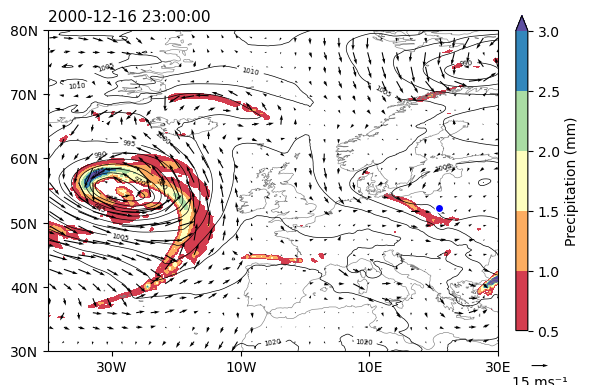

In [79]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-30, -10, 10, 30] 
lats_tick = [80, 70, 60, 50, 40, 30]
colorvim_levels = np.arange(0.5, 3.5, 0.5)
cbar = np.arange(960, 1025, 5) 

fig, ax = plt.subplots(1,1,sharey=True, sharex=True, figsize=(6., 7.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=0.85, color='grey')  
contf = ax.contourf(lons, lats, prec.sel(time=timesel[0]), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, 
                    extend='max', transform=datacrs, zorder=0)

fig.subplots_adjust(left=0.1, bottom=0.1, right=0.85, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([0.88, 0.3, 0.02, 0.45])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=50)
cb.set_label('Precipitation (mm)')
timesel = pd.date_range(start='2000-12-11 00:00:00', end='2000-12-16 23:00:00', freq='H')

def update(time):
    ax.clear()
    ax.set_extent(boundary, crs=datacrs) 
    ax.set_xticks(lons_tick, crs=datacrs)  
    ax.set_yticks(lats_tick, crs=datacrs)  
    time_track = pd.to_datetime(time)
    track_lon = sel_trx.loc[sel_trx['date'] == time_track, 'lon_vor']
    track_lat = sel_trx.loc[sel_trx['date'] == time_track, 'lat_vor']
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.coastlines(linewidth=0.45, color='grey')

    contf = ax.contourf(lons, lats, prec.sel(time=time), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, extend='max', transform=datacrs, zorder=0)
    skip=(slice(None,None,9),slice(None,None,9))
    wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd.sel(time=time)[skip], vwnd.sel(time=time)[skip], 
                                pivot='tail', transform=datacrs, zorder=5)
    contour_lines = ax.contour(lons, lats, msl.sel(time=time), cbar, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
    ax.clabel(contour_lines, inline=True, fontsize=5, fmt='%.0f')
    ax.quiverkey(wind_vec_plot, 0.92, 0.25, 15, '15 ms⁻¹', labelpos='S', zorder=24,
                   coordinates='figure')    
    ax.plot(track_lon, track_lat, 'o', color='blue', markersize=6, markeredgecolor='white',
            markerfacecolor='blue', transform=datacrs, zorder=21)
    ax.set_title(f'{time}', weight='normal', loc='left', fontsize=11)


# Create the animation
ani = FuncAnimation(fig, update, frames=timesel, repeat=False)
ani.save('full_dec_2000_track.mp4', writer='ffmpeg', fps=2, dpi=300)

plt.show()


## ERA5 with Track

In [19]:
dec_mslp = xr.open_dataset('dec_mslp.nc')
msl_ = dec_mslp['msl'] / 100
msl_clim = msl_.mean(dim='time')

In [20]:
msl_anom = msl - msl_clim
lonsi = msl_anom['longitude']
latsi = msl_anom['latitude']

msl_anom_all = msl_anom.mean(dim='time')

In [44]:
trx = pd.DataFrame()
file_path = f'Track/ERA5_VOR850_1hr_oct-mar20002001_NORTHSEA_minwindspeed25.csv'
trx_data = pd.read_csv(file_path)
trx = pd.concat([trx, trx_data], ignore_index=True) 
trx['lon_vor'] = ((trx['lon_vor'] + 180) % 360) - 180
trx = calc_speed_dir(trx, 1)
trx['bearing'] = trx['bearing'].apply(adjust_bearing)
trx.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
0,11154,2000-10-07 00:00:00,-53.519684,45.373074,2.840744,NaN,NaN,1022.430,313.0312,43.70022,...,44.82434,12.27273,817,2000-10-07 00:00:00,NaN,unknown,2000-2001,99.594405,27.665112,81.837036
1,11155,2000-10-07 01:00:00,-52.258423,45.493359,2.937945,NaN,NaN,1023.302,308.2500,44.26228,...,46.22949,12.46351,817,2000-10-07 00:00:00,NaN,unknown,2000-2001,84.872167,23.575602,78.213554
2,11156,2000-10-07 02:00:00,-51.192657,45.644379,3.011562,NaN,NaN,1023.772,309.6562,44.54331,...,45.94846,12.36212,817,2000-10-07 00:00:00,NaN,unknown,2000-2001,73.186912,20.329698,74.066763
3,11157,2000-10-07 03:00:00,-50.287048,45.821560,3.078489,NaN,NaN,1023.596,310.5000,44.54331,...,45.94846,12.23912,817,2000-10-07 00:00:00,NaN,unknown,2000-2001,61.897106,17.193641,72.441983
4,11158,2000-10-07 04:00:00,-49.525391,45.987022,3.112185,309.7233,44.45288,1020.817,311.9062,44.54331,...,45.94846,11.87355,817,2000-10-07 00:00:00,NaN,unknown,2000-2001,63.252821,17.570228,71.060531


In [45]:
#storm_id_sel = [9619, 9977, 10288, 10495, 10031, 10821, 10868, 10844]
storm_id_sel = [9619, 9977, 10495, 10031, 10821]
trx_sel = trx[trx['ID'].isin(storm_id_sel)]
trx_sel['date'] = pd.to_datetime(trx_sel['date'])

/tmp/ipykernel_3002/966233551.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_sel['date'] = pd.to_datetime(trx_sel['date'])


In [42]:
trx_sel[trx_sel['var_vor']==13.56644]

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
1038,92585,2000-12-09 22:00:00,-28.706879,53.07827,13.56644,331.4521,52.95472,955.8128,329.9062,51.85009,...,51.56907,24.79895,10031,2000-12-08 21:00:00,NaN,unknown,2000-2001,16.64869,4.624636,73.500801


In [41]:
trx_sel[trx_sel['ID']==10031]['var_vor'].max()
#trx_sel[(trx_sel['ID']==9619) & (trx_sel['var_vor']==19.4299)]#or (trx_sel['var_mslp']==959.1636) or 
#trx_sel[trx_sel['ID']==10821]['var_mslp'].min()
#trx_sel[(trx_sel['ID']==10821) & (trx_sel['var_mslp']==960.3788)]

13.56644

In [43]:
distA = trx_sel[trx_sel['ID']==10031]['distance'].sum()
distA2 = trx_sel[trx_sel['ID']==10495]['distance'].sum()
distA

5255.529602990623

In [38]:
distA = trx_sel[trx_sel['ID']==10031]['date'].max()
distA2 = trx_sel[trx_sel['ID']==10031]['date'].min()
#distB = trx_sel[trx_sel['ID']==10821]['date'].max()
#distB2 = trx_sel[trx_sel['ID']==10821]['date'].min()
(distA - distA2)#+(distB - distB2)

Timedelta('5 days 03:00:00')

In [ ]:
import matplotlib.dates as mdates
import matplotlib.units as munits
import datetime

formats = ['%y',          # ticks are mostly years
           '%b',     # ticks are mostly months
           '%d',     # ticks are mostly days
           '%HZ',  # hrs
           '%H:%M',  # min
           '%S.%f', ]  # secs
zero_formats = [''] + formats[:-1]
zero_formats[3] = '%HZ\n%d %b %Y'
waktuini = (np.datetime64('2000-12-06T00:00'), np.datetime64('2000-12-17T18:00'))

/tmp/ipykernel_521/3847478692.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


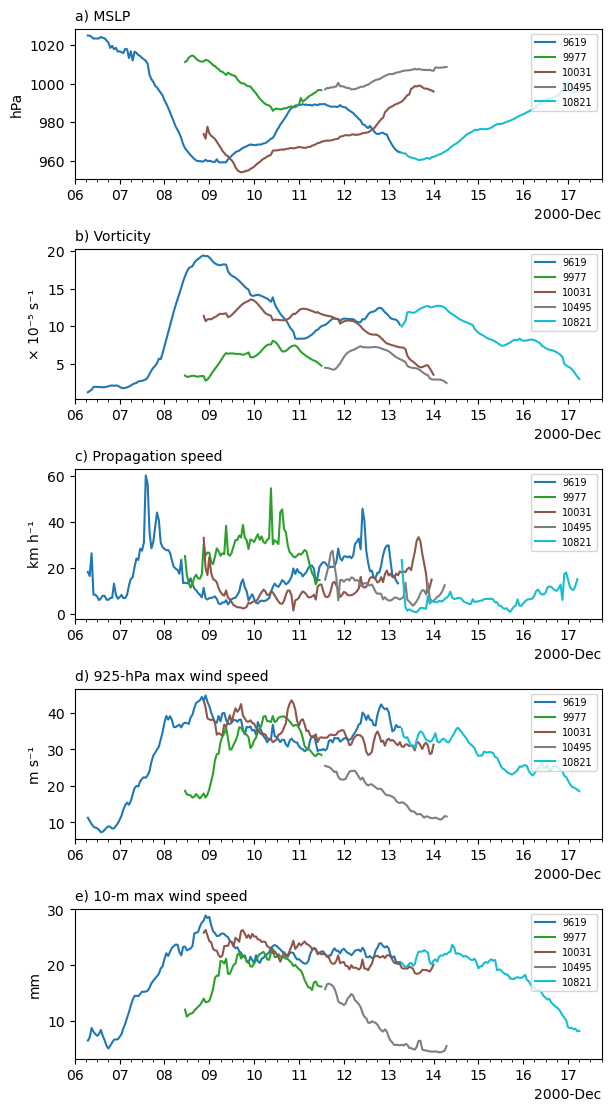

In [16]:
fig, axs = plt.subplots(figsize=(6., 11.), nrows=5, ncols=1, constrained_layout=True)
converter = mdates.ConciseDateConverter(formats=formats, zero_formats=zero_formats, show_offset=0)
locator = mdates.AutoDateLocator(minticks=6, maxticks=24)
formatter = mdates.ConciseDateFormatter(locator)

# Set x-axis locator and formatter for all subplots
for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
    ax.set_xlim(waktuini)

# Plot data for each variable
variables = ['var_mslp', 'var_vor', 'speed', 'var_wind', 'var_prec']  # Assuming these are your variables
titles = ['a) MSLP', 'b) Vorticity', 'c) Propagation speed', 'd) 925-hPa max wind speed', 'e) 10-m max wind speed']
ylabels = ['hPa', '× 10⁻⁵ s⁻¹', 'km h⁻¹', 'm s⁻¹', 'mm']
cmap = cm.get_cmap('tab10', len(storm_id_sel))
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    for storm_idx, (name, group) in enumerate(trx_sel.groupby('ID')):
        if var in group.columns:
            color = cmap(storm_idx)
            axs[idx].plot(group['date'], group[var], label=f'{name}', color=color)
        else:
            print(f"Variable {var} not found in group columns")
            
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].legend(frameon=True, fancybox=True, fontsize=7, loc='upper right')

plt.show()


/tmp/ipykernel_521/3334932153.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


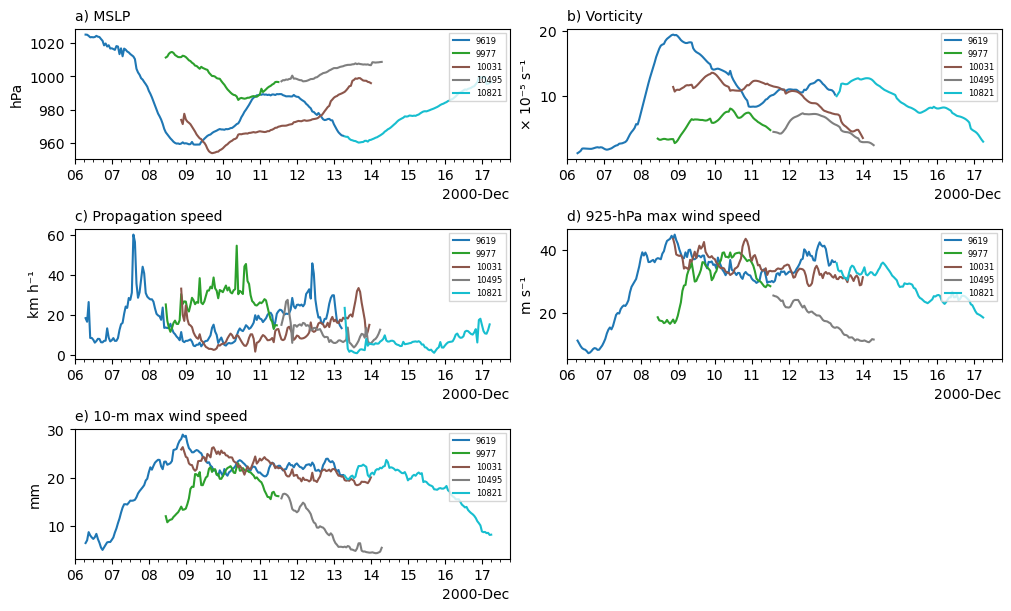

In [22]:
fig, axs = plt.subplots(3, 2, figsize=(10., 6.), constrained_layout=True)
axs = axs.flatten()
converter = mdates.ConciseDateConverter(formats=formats, zero_formats=zero_formats, show_offset=0)
locator = mdates.AutoDateLocator(minticks=6, maxticks=24)
formatter = mdates.ConciseDateFormatter(locator)

for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
    ax.set_xlim(waktuini)

# Plot data for each variable
variables = ['var_mslp', 'var_vor', 'speed', 'var_wind', 'var_prec'] 
titles = ['a) MSLP', 'b) Vorticity', 'c) Propagation speed', 'd) 925-hPa max wind speed', 'e) 10-m max wind speed']
ylabels = ['hPa', '× 10⁻⁵ s⁻¹', 'km h⁻¹', 'm s⁻¹', 'mm']
cmap = cm.get_cmap('tab10', len(storm_id_sel))
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    for storm_idx, (name, group) in enumerate(trx_sel.groupby('ID')):
        if var in group.columns:
            color = cmap(storm_idx)
            axs[idx].plot(group['date'], group[var], label=f'{name}', color=color)
        else:
            print(f"Variable {var} not found in group columns")
            
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].legend(frameon=True, fancybox=False, fontsize=6, loc='upper right')

for ax in axs[len(variables):]:
    fig.delaxes(ax)
plt.show()


/tmp/ipykernel_1159/2132680992.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


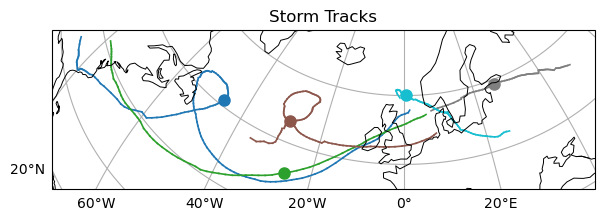

In [92]:
datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': mapcrs})
ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

cmap = cm.get_cmap('tab10', len(storm_id_sel))

# Group the selected DataFrame by 'ID' and plot each group with a different color
for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)  # Get a unique color for each storm track
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        ax.plot(line[:, 0], line[:, 1], color=color, linewidth=1.2, transform=datacrs)
    
    # Find the point with the minimum var_mslp value
    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=8, transform=datacrs)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Storm Tracks')

plt.show()


## Synop Map

/tmp/ipykernel_1159/2260590247.py:33: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in cs.collections:
/tmp/ipykernel_1159/2260590247.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


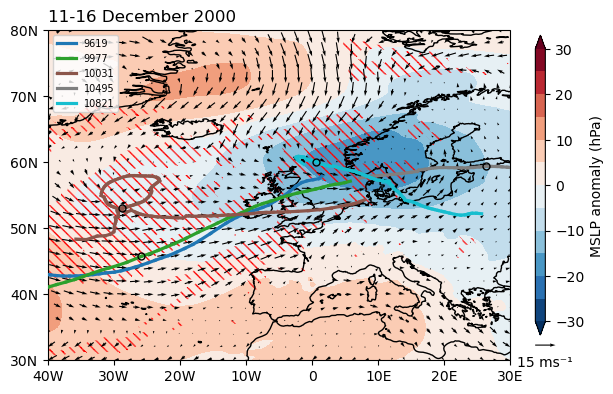

In [94]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(5., 5.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(-30, 35, 5)
contf = ax.contourf(lonsi, latsi, msl_anom_all, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)

skip=(slice(None,None,8),slice(None,None,8))
wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd_all[skip], vwnd_all[skip], 
                              pivot='tip', transform=datacrs, zorder=5)

ax.quiverkey(wind_vec_plot, 1.12, 0.2, 15, '15 ms⁻¹', labelpos='S', zorder=24,
                   coordinates='figure')

col_map = np.arange(30, 110, 10)
#contf_prec = ax.contourf(lons, lats, prec_sum, levels=col_map, vmin=40, cmap=plt.cm.viridis, extend='max', 
#                    transform=datacrs, alpha=0.6, zorder=10)

levels = np.linspace(30, np.max(prec_sum), num=50)
prec_sum_masked = np.ma.masked_less_equal(prec_sum, 30)
cs = ax.contourf(lons, lats, prec_sum_masked, levels=levels, hatches=['\\\\\\'], vmin=25, extend='max', colors='None',
                 transform=datacrs)
for collection in cs.collections:
    collection.set_edgecolor('red')
    collection.set_linewidth(0)
    
cmap = cm.get_cmap('tab10', len(storm_id_sel))
lines = []
labels = []

for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)  # Get a unique color for each storm track
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        line_obj, = ax.plot(line[:, 0], line[:, 1], color=color, linewidth=2.3, transform=datacrs, zorder=20)
        
    lines.append(line_obj)
    labels.append(f'{name}')

    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=5, markeredgecolor='black',
            markerfacecolor='None', transform=datacrs, zorder=21)

ax.set_title('11-16 December 2000', weight='normal', loc='left')
ax.legend(lines, labels, loc='upper left', fontsize=7)

fig.subplots_adjust(bottom=0.1, right=1.05, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([1.1, 0.22, 0.02, 0.6])
#dax = fig.add_axes([1.3, 0.22, 0.02, 0.6])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=20)
cb.set_label('MSLP anomaly (hPa)')

#pr = plt.colorbar(contf_prec, cax=dax, orientation='vertical', aspect=20)
#pr.set_label('Total precipitation (mm)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import xarray as xr
fpath_badc = '/badc/ukmo-hadobs/data/insitu/MOHC/HadOBS/HadUK-Grid/v1.3.0.ceda/12km/rainfall/day/v20240514/'
raindat_path = 'rainfall_hadukgrid_uk_12km_day_20001201-20001231.nc'

raindat = xr.open_dataset(fpath_badc+raindat_path)
raindat

<xarray.Dataset> Size: 2MB
Dimensions:                       (time: 31, projection_y_coordinate: 112,
                                   projection_x_coordinate: 82, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 248B 2000-12-01T12:00...
  * projection_y_coordinate       (projection_y_coordinate) float64 896B -1.0...
  * projection_x_coordinate       (projection_x_coordinate) float64 656B -2.1...
    latitude                      (projection_y_coordinate, projection_x_coordinate) float64 73kB ...
    longitude                     (projection_y_coordinate, projection_x_coordinate) float64 73kB ...
Dimensions without coordinates: bnds
Data variables:
    rainfall                      (time, projection_y_coordinate, projection_x_coordinate) float64 2MB ...
    transverse_mercator           int32 4B ...
    time_bnds                     (time, bnds) datetime64[ns] 496B ...
    projection_y_coordinate_bnds  (projection_y_coordinate, bnds) float64 2kB ...
    projection_x_coordinate_bnds  (projection_x_coordinate, bnds) float64 1kB ...
Attributes:
    comment:        Daily resolution gridded climate observations
    creation_date:  2024-05-17T12:53:04
    frequency:      day
    institution:    Met Office
    references:     doi: 10.1002/gdj3.78
    short_name:     daily_rainfall
    source:         HadUK-Grid_v1.3.0.0
    title:          Gridded surface climate observations data for the UK
    version:        v20240514
    Conventions:    CF-1.7

In [2]:
raindat.to_netcdf("rainfall_hadukgrid_uk_12km_day_20001201-20001231.nc")

In [10]:
from pyproj import Proj, transform
import numpy as np
proj_proj = Proj(proj="tmerc", lat_0=49.0, lon_0=-2.0, k=0.9996012717, x_0=400000.0, y_0=-100000.0, datum="WGS84")
proj_wgs84 = Proj(proj="latlong", datum="WGS84")

In [11]:
y_coor = raindat['projection_y_coordinate'].values
x_coor = raindat['projection_x_coordinate'].values

# Assuming x_coords and y_coords are 1D
x_grid, y_grid = np.meshgrid(x_coor, y_coor)
x_flat = x_grid.ravel()
y_flat = y_grid.ravel()

# Transform the flattened coordinates
lon_flat, lat_flat = transform(proj_proj, proj_wgs84, x_flat, y_flat)
lon_coords = lon_flat.reshape(x_grid.shape)
lat_coords = lat_flat.reshape(y_grid.shape)

raindat = raindat.assign_coords(longitude=(('latitude', 'longitude'), lon_coords),
                                latitude=(('latitude', 'longitude'), lat_coords))

# Inspect the dataset with new coordinates
print(raindat['longitude'].max().values)

"""
trans_merc = raindat['transverse_mercator']

long = raindat['longitude']
latg = raindat['latitude']

long, latg = transform(proj_proj, proj_wgs84, x_coor, y_coor)
raindat = raindat.assign_coords(longitude=('longitude', long), latitude=('latitude', latg))
"""
#lon_coords.max()

4.656456197588377


/tmp/ipykernel_3002/2068394457.py:10: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon_flat, lat_flat = transform(proj_proj, proj_wgs84, x_flat, y_flat)


"\ntrans_merc = raindat['transverse_mercator']\n\nlong = raindat['longitude']\nlatg = raindat['latitude']\n\nlong, latg = transform(proj_proj, proj_wgs84, x_coor, y_coor)\nraindat = raindat.assign_coords(longitude=('longitude', long), latitude=('latitude', latg))\n"

In [22]:
# Access the rainfall data array
rainfall = raindat['rainfall']

# Extract the data from the longitude and latitude DataArrays
lon_data = raindat['longitude'].data
lat_data = raindat['latitude'].data

# Rename the existing dimensions in the rainfall array
rainfall = rainfall.rename({'projection_y_coordinate': 'latitude', 'projection_x_coordinate': 'longitude'})

# Assign the new longitude and latitude coordinates
rainfall = rainfall.assign_coords(longitude=(('latitude', 'longitude'), lon_data),
                                  latitude=(('latitude', 'longitude'), lat_data))

raindat['rainfall'] = rainfall

<xarray.DataArray 'rainfall' (time: 31, latitude: 112, longitude: 82)> Size: 2MB
[284704 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 248B 2000-12-01T12:00:00 ... 2000-12-31T...
    latitude   (latitude, longitude) float64 73kB 48.68 48.69 ... 60.8 60.79
    longitude  (latitude, longitude) float64 73kB -10.29 -10.13 ... 4.437 4.656
Attributes:
    standard_name:  lwe_thickness_of_precipitation_amount
    long_name:      Total rainfall
    units:          mm
    description:    Total rainfall
    label_units:    mm
    level:          NA
    plot_label:     Total rainfall (mm)
    cell_methods:   time: sum
    grid_mapping:   transverse_mercator


In [31]:
prec = raindat.sel(time=slice('2000-12-06T12:00:00','2000-12-17T12:00:00'))['rainfall']
prec_sum = prec.sum(dim='time')
prec_sum.max()

<xarray.DataArray 'rainfall' ()> Size: 8B
array(267.14615247)

/tmp/ipykernel_3002/3227931541.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


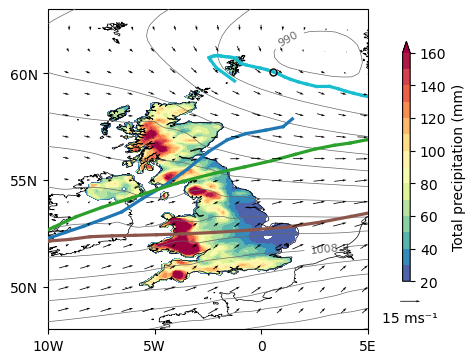

In [71]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-10, 5, 48, 63]
lons_tick = [-10, -5, 0, 5]
lats_tick = [50, 55, 60]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(3.8, 4.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=0.5)  

cbar = np.arange(980, 1020, 2) 
colorvim_levels = np.arange(20, 170, 10)
contf = ax.contourf(lon_data, lat_data, prec_sum, levels=colorvim_levels, cmap=plt.cm.Spectral_r, extend='max', transform=datacrs, zorder=0)
skip=(slice(None,None,4),slice(None,None,4))
wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd_all[skip], vwnd_all[skip], scale=240, pivot='tip', transform=datacrs, zorder=25)
ax.quiverkey(wind_vec_plot, 1.12, 0.17, 15, '15 ms⁻¹', labelpos='S', zorder=24, coordinates='figure')
contour_lines = ax.contour(lons, lats, msl_mean, cbar, colors='dimgrey', linewidths=0.5, zorder=10, transform=datacrs)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.0f')

cmap = cm.get_cmap('tab10', len(storm_id_sel))
lines = []
labels = []

for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)  # Get a unique color for each storm track
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        line_obj, = ax.plot(line[:, 0], line[:, 1], color=color, linewidth=2.3, transform=datacrs, zorder=20)
        
    lines.append(line_obj)
    labels.append(f'{name}')

    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=5, markeredgecolor='black',
            markerfacecolor='None', transform=datacrs, zorder=21)


#ax.set_title('11-16 December 2000', weight='normal', loc='left')

fig.subplots_adjust(bottom=0.1, right=1.05, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([1.1, 0.22, 0.02, 0.6])
#dax = fig.add_axes([1.3, 0.22, 0.02, 0.6])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=20)
cb.set_label('Total precipitation (mm)')

#pr = plt.colorbar(contf_prec, cax=dax, orientation='vertical', aspect=20)
#pr.set_label('Total precipitation (mm)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
timesel = ['2000-12-11T12:00:00', '2000-12-11T18:00:00', '2000-12-12T00:00:00',
            '2000-12-12T06:00:00', '2000-12-12T12:00:00', '2000-12-12T18:00:00',
            '2000-12-13T00:00:00', '2000-12-13T06:00:00', '2000-12-13T12:00:00', 
            '2000-12-13T18:00:00', '2000-12-14T00:00:00', '2000-12-14T06:00:00']

timesel_track = ['2000-12-11 12:00:00', '2000-12-11 18:00:00', '2000-12-12 00:00:00',
            '2000-12-12 06:00:00', '2000-12-12 12:00:00', '2000-12-12 18:00:00',
            '2000-12-13 00:00:00', '2000-12-13 06:00:00', '2000-12-13 12:00:00', 
            '2000-12-13 18:00:00', '2000-12-14 00:00:00', '2000-12-14 06:00:00']

for i in timesel:
    print(i)

2000-12-11T12:00:00
2000-12-11T18:00:00
2000-12-12T00:00:00
2000-12-12T06:00:00
2000-12-12T12:00:00
2000-12-12T18:00:00
2000-12-13T00:00:00
2000-12-13T06:00:00
2000-12-13T12:00:00
2000-12-13T18:00:00
2000-12-14T00:00:00
2000-12-14T06:00:00


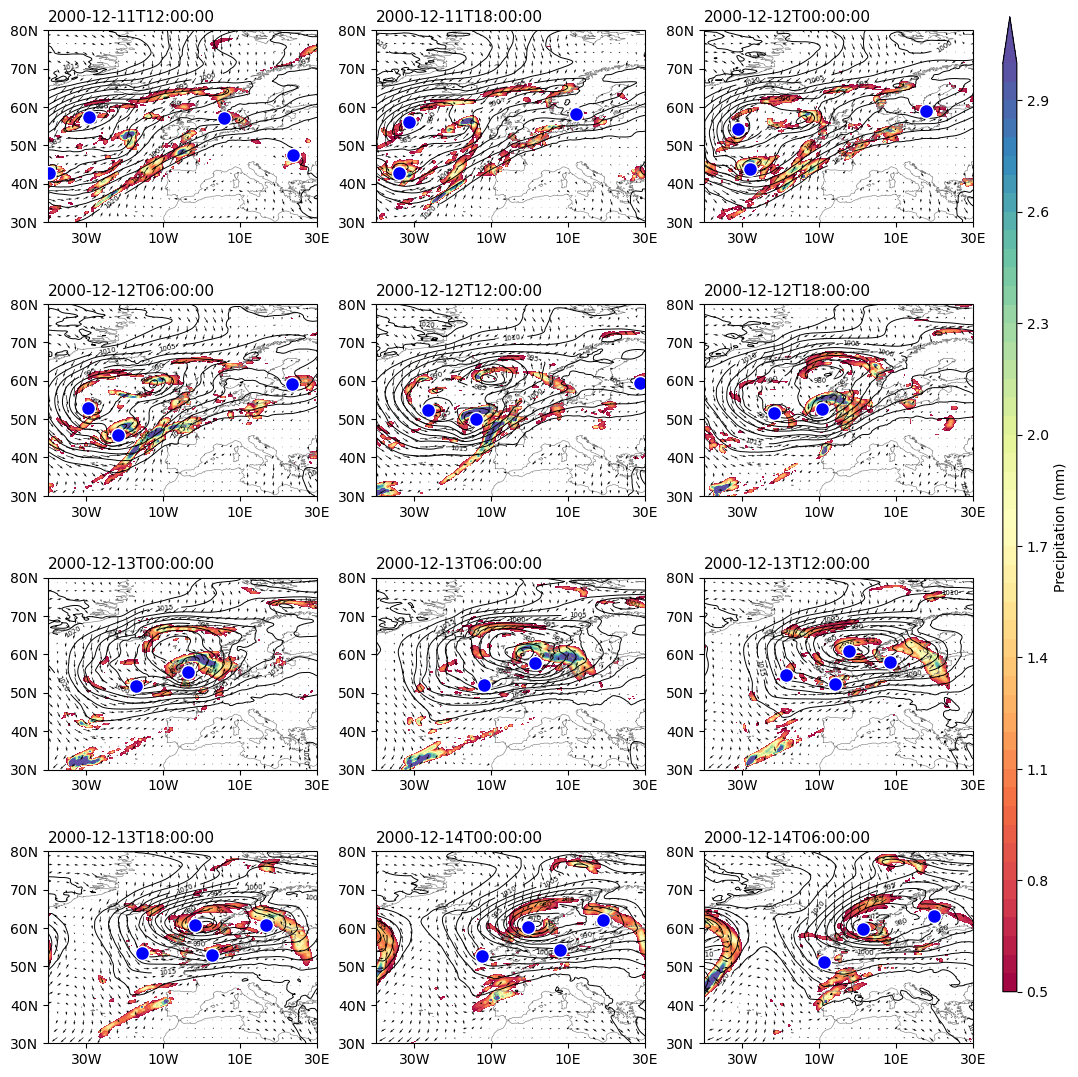

In [69]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-30, -10, 10, 30] # longitude yg mau dikasih tickmark
lats_tick = [80, 70, 60, 50, 40, 30] # latitude yg mau dikasih tickmark

fig, axs = plt.subplots(4, 3, sharey=True, sharex=True, figsize=(10., 13.), subplot_kw={'projection': datacrs})
axs = axs.ravel()  # Ubah array 2D dari axs jadi 1D supaya lebih gampang di-loop

# Loop untuk setiap axes untuk plotting
for i, ax in enumerate(axs):
    time = timesel[i]
    time_track = timesel_track[i]
    track_lon = trx_sel.loc[trx_sel['date'] == time_track, 'lon_vor']
    track_lat = trx_sel.loc[trx_sel['date'] == time_track, 'lat_vor']
    ax.set_extent(boundary, crs=datacrs) 
    ax.set_xticks(lons_tick, crs=datacrs)  
    ax.set_yticks(lats_tick, crs=datacrs)  
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.coastlines(linewidth=0.45, color='grey')  

    colorvim_levels = np.arange(0.5, 3.05, 0.05)
    contf = ax.contourf(lons, lats, prec.sel(time=time), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, extend='max', transform=datacrs, zorder=0)

    skip=(slice(None,None,9),slice(None,None,9))
    wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd.sel(time=time)[skip], vwnd.sel(time=time)[skip], 
                              pivot='tail', transform=datacrs, zorder=5)
    
    cbar = np.arange(960, 1025, 5)
    contour_lines = ax.contour(lons, lats, msl.sel(time=time), cbar, colors='black', linewidths=0.7, zorder=10, transform=datacrs)
    plt.clabel(contour_lines, inline=True, fontsize=5, fmt='%.0f')
    ax.plot(track_lon, track_lat, 'o', color='blue', markersize=10, markeredgecolor='white',
            markerfacecolor='blue', transform=datacrs, zorder=21)
    
    ax.set_title(f'{time}', weight='normal', loc='left', fontsize=11)

fig.subplots_adjust(bottom=0.1, right=1.05, top=0.9, wspace=0.22, hspace=0.25)
cax = fig.add_axes([1.08, 0.15, 0.014, 0.75])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=50)
cb.set_label('Precipitation (mm)')
#plt.savefig('fig_ex.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
specific_date = '2000-12-11 08:00:00'
specific_date = '2000-12-11T12:00:00'
filtered_data = trx_sel.loc[trx_sel['date'] == specific_date, 'lon_vor']
filtered_data

Series([], Name: lon_vor, dtype: float64)

In [212]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-pressure-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            'potential_vorticity', 'vorticity',
        ],
        'pressure_level': '850',
        'year': '2022',
        'month': '03',
        'day': '15',
        'time': '00:00',
        'format': 'netcdf',
    },
    'download.nc')

2024-06-18 14:32:26,945 INFO Welcome to the CDS
2024-06-18 14:32:26,946 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-pressure-levels
2024-06-18 14:32:27,035 INFO Request is queued
2024-06-18 14:32:28,074 INFO Request is running
2024-06-18 14:32:29,612 INFO Request is completed
2024-06-18 14:32:29,613 INFO Downloading https://download-0009-clone.copernicus-climate.eu/cache-compute-0009/cache/data5/adaptor.mars.internal-1718721147.926137-10899-5-8b9b4c3e-3765-420e-97f4-300d526bd7dd.nc to download.nc (4M)
2024-06-18 14:32:30,123 INFO Download rate 7.8M/s   


Result(content_length=4162996,content_type=application/x-netcdf,location=https://download-0009-clone.copernicus-climate.eu/cache-compute-0009/cache/data5/adaptor.mars.internal-1718721147.926137-10899-5-8b9b4c3e-3765-420e-97f4-300d526bd7dd.nc)

In [213]:
datex = xr.open_dataset('download.nc')
datex

<xarray.Dataset> Size: 17MB
Dimensions:    (longitude: 1440, latitude: 721, time: 1)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 8B 2022-03-15
Data variables:
    pv         (time, latitude, longitude) float64 8MB ...
    vo         (time, latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-06-18 14:32:28 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...